In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir('/Users/syedamishrasaiara/pythonprojects/SQL_Analytics')
DATA = "data/yellow_tripdata_2024-01.parquet"
os.makedirs('charts', exist_ok=True)
print("Ready!")

Ready!


## Revenue Analysis — NYC Yellow Taxi (January 2024)
Exploring revenue patterns by payment type, tip behavior, 
and fare components to understand what drives income.

In [ ]:
#Revenue by payment type
payment = duckdb.sql(f"""
    SELECT
        CASE payment_type
            WHEN 1 THEN 'Credit Card'
            WHEN 2 THEN 'Cash'
            WHEN 3 THEN 'No Charge'
            WHEN 4 THEN 'Dispute'
            ELSE 'Unknown'
        END AS payment_method,
        COUNT(*) AS trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(tip_amount), 2) AS avg_tip,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM '{DATA}'
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""").df()

payment

,payment_method,trips,avg_fare,avg_tip,total_revenue
0,Credit Card,2298390,18.38,4.16,64528784.34
1,Cash,422753,18.62,0.00,10089183.61
2,Unknown,115249,20.37,1.84,3056745.60
3,Dispute,22759,19.77,0.00,571936.35
4,No Charge,10563,17.18,0.01,235422.62


In [3]:
#Tip rate analysis
tips = duckdb.sql(f"""
    WITH tip_flags AS (
        SELECT
            tip_amount,
            fare_amount,
            ROUND(tip_amount / fare_amount * 100, 1) AS tip_pct,
            CASE
                WHEN tip_amount = 0 THEN 'No tip'
                WHEN tip_amount / fare_amount < 0.15 THEN 'Below 15%'
                WHEN tip_amount / fare_amount < 0.20 THEN '15–20%'
                WHEN tip_amount / fare_amount < 0.25 THEN '20–25%'
                ELSE 'Above 25%'
            END AS tip_bucket
        FROM '{DATA}'
        WHERE payment_type = 1
          AND fare_amount > 0
          AND tip_amount >= 0
    )
    SELECT tip_bucket,
           COUNT(*) AS trips,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) AS pct_of_trips
    FROM tip_flags
    GROUP BY tip_bucket
    ORDER BY trips DESC
""").df()

tips

,tip_bucket,trips,pct_of_trips
0,Above 25%,1343967,58.0
1,20–25%,423874,18.3
2,Below 15%,277165,12.0
3,15–20%,159802,6.9
4,No tip,114050,4.9


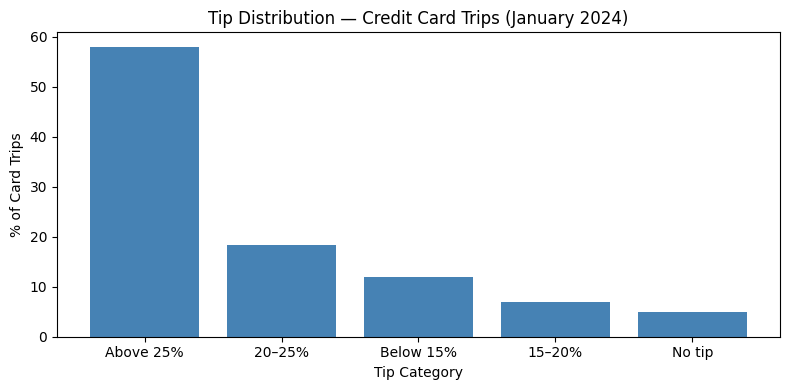

In [4]:
#Visualize tip buckets
plt.figure(figsize=(8, 4))
plt.bar(tips['tip_bucket'], tips['pct_of_trips'], color='steelblue')
plt.xlabel('Tip Category')
plt.ylabel('% of Card Trips')
plt.title('Tip Distribution — Credit Card Trips (January 2024)')
plt.tight_layout()
plt.savefig('charts/tip_distribution.png', dpi=150)
plt.show()

In [5]:
#Fare breakdown components
components = duckdb.sql(f"""
    SELECT
        ROUND(AVG(fare_amount), 2) AS avg_base_fare,
        ROUND(AVG(tip_amount), 2) AS avg_tip,
        ROUND(AVG(tolls_amount), 2) AS avg_tolls,
        ROUND(AVG(improvement_surcharge), 2) AS avg_surcharge,
        ROUND(AVG(total_amount), 2) AS avg_total
    FROM '{DATA}'
    WHERE fare_amount > 0 AND trip_distance > 0
""").df()

components

,avg_base_fare,avg_tip,avg_tolls,avg_surcharge,avg_total
0,18.5,3.4,0.54,1.0,27.35


## Key Findings

- **Credit card dominates massively**: 2.3M card trips vs 422K cash trips — 
  card payments account for ~84% of all revenue ($64.5M vs $10M for cash)
- **Cash trips never tip**: Cash passengers report exactly $0 avg tip, confirming 
  tips are off-meter — making each card trip worth significantly more to drivers
- **NYC riders tip generously**: A striking **58% of card trips tip above 25%**, 
  far exceeding the standard 20% — only 4.9% of card payers leave no tip at all
- **Fare components**: Avg base fare is $18.50, avg tip adds $3.40, tolls $0.54, 
  and surcharges $1.00 — bringing the avg total to $27.35 per trip
- **Unknown payment type**: 115K trips show an unknown payment type with $1.84 
  avg tip — likely a system or app-based payment category worth investigating